<a href="https://colab.research.google.com/github/bpucalderon001/SpringBreak/blob/main/Impacr_SpringBreak.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pylab inline
!pip install keras-unet -q

Populating the interactive namespace from numpy and matplotlib


In [2]:
!wget -q --show-progress https://thor.robots.ox.ac.uk/~vgg/data/pets/images.tar.gz
!wget -q --show-progress https://thor.robots.ox.ac.uk/~vgg/data/pets/annotations.tar.gz
!tar -xzf images.tar.gz
!tar -xzf annotations.tar.gz
print('Done!')

images.tar.gz       100%[===================>] 755.23M  22.4MB/s    in 36s     
annotations.tar.gz  100%[===================>]  18.28M  9.36MB/s    in 2.0s    
Done!


In [3]:
import numpy as np
from PIL import Image

CLASS_NAME = 'Abyssinian'
IMG_SIZE = 320

image_names = []
with open('annotations/list.txt') as f:
    for line in f:
        if line.startswith('#'):
            continue
        name = line.strip().split()[0]
        if name.startswith(CLASS_NAME):
            image_names.append(name)

print(f'Found {len(image_names)} images for: {CLASS_NAME}')

Found 198 images for: Abyssinian


In [4]:
def load_sample(name):
    img  = Image.open(f'images/{name}.jpg').convert('L')
    mask = Image.open(f'annotations/trimaps/{name}.png')
    img  = img.resize((IMG_SIZE, IMG_SIZE))
    mask = mask.resize((IMG_SIZE, IMG_SIZE), Image.NEAREST)
    img  = np.array(img,  dtype=np.float32) / 255.0
    mask = (np.array(mask, dtype=np.float32) == 1).astype(np.float32)
    return img, mask

imgs_list, masks_list = [], []
for name in image_names:
    try:
        img, mask = load_sample(name)
        imgs_list.append(img)
        masks_list.append(mask)
    except Exception as e:
        print(f'Skipped {name}: {e}')

images = np.array(imgs_list)[..., None]
masks  = np.array(masks_list)[..., None]
print(f'Loaded {len(images)} samples — images: {images.shape}, masks: {masks.shape}')

Loaded 198 samples — images: (198, 320, 320, 1), masks: (198, 320, 320, 1)


In [5]:
split = int(0.85 * len(images))
X_train, y_train = images[:split], masks[:split]
X_test,  y_test  = images[split:], masks[split:]
print(f'Train: {len(X_train)}  |  Test: {len(X_test)}')

Train: 168  |  Test: 30


In [6]:
from keras_unet.models import custom_unet

model = custom_unet(
    input_shape=(320, 320, 1),
    use_batch_norm=True,
    num_classes=1,
    filters=64,
    dropout=0.2,                    # DROPOUT
    dropout_change_per_layer=0.0,
    output_activation='sigmoid'
)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()

-----------------------------------------
keras-unet init: TF version is >= 2.0.0 - using `tf.keras` instead of `Keras`
-----------------------------------------


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 320, 320,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 320, 320,  │        576 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 320, 320,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d   │ (None, 320, 320,  │          0 │ batch_normalizat… │
│ (SpatialDropout2D)  │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 320, 320,  │     36,864 │ spatial_dropout2… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 320, 320,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 160, 160,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 160, 160,  │     73,728 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 160, 160,  │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d_1 │ (None, 160, 160,  │          0 │ batch_normalizat… │
│ (SpatialDropout2D)  │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 160, 160,  │    147,456 │ spatial_dropout2… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 160, 160,  │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 80, 80,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 80, 80,    │    294,912 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 80, 80,    │      1,024 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d_2 │ (None, 80, 80,    │          0 │ batch_normalizat… │
│ (SpatialDropout2D)  │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 80, 80,    │    589,824 │ spatial_dropout2

 Total params: 31,048,257 (118.44 MB)

 Trainable params: 31,036,481 (118.39 MB)

 Non-trainable params: 11,776 (46.00 KB)

In [7]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint(
    filepath='best_model.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

print('Callbacks ready.')

Callbacks ready.


In [8]:
history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=50,
    batch_size=8,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5076 - loss: 0.8279  
Epoch 1: val_loss improved from None to 4161.12988, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
19/19 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - accuracy: 0.5616 - loss: 0.7396 - val_accuracy: 0.4879 - val_loss: 4161.1299
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.6784 - loss: 0.6277
Epoch 2: val_loss improved from 4161.12988 to 2507.78125, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 137ms/step - accuracy: 0.7013 - loss: 0.6080 - val_accuracy: 0.3664 - val_loss: 2507.7812
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.7719 - loss: 0.5292
Epoch 3: val_loss improved from 2507.78125 to 261.28055, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 137ms/step - accuracy: 0.7525 - loss: 0.5365 - val_accuracy: 0.3663 - val_loss: 261.2805
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.7828 - loss: 0.5004
Epoch 4: val_loss improved from 261.28055 to 93.98335, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 144ms/step - accuracy: 0.7682 - loss: 0.5192 - val_accuracy: 0.3971 - val_loss: 93.9834
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.7514 - loss: 0.5129
Epoch 5: val_loss improved from 93.98335 to 34.04934, saving model to best_model.h5


...


Epoch 22: finished saving model to best_model.h5
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 127ms/step - accuracy: 0.8643 - loss: 0.3144 - val_accuracy: 0.8015 - val_loss: 0.5376
Epoch 23/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.8696 - loss: 0.3009
Epoch 23: val_loss improved from 0.53761 to 0.50429, saving model to best_model.h5



Epoch 23: finished saving model to best_model.h5
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 219ms/step - accuracy: 0.8654 - loss: 0.3092 - val_accuracy: 0.8418 - val_loss: 0.5043
Epoch 24/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.8577 - loss: 0.3233
Epoch 24: val_loss did not improve from 0.50429
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.8628 - loss: 0.3118 - val_accuracy: 0.7980 - val_loss: 0.6810
Epoch 25/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.8667 - loss: 0.3051
Epoch 25: val_loss did not improve from 0.50429
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.8622 - loss: 0.3156 - val_accuracy: 0.8009 - val_loss: 0.6809
Epoch 26/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.8558 - loss: 0.3148
Epoch 26: val_loss improved from 0.50429 to 0.39622, saving model to best_model.h5



Epoch 26: finished saving model to best_model.h5
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 133ms/step - accuracy: 0.8640 - loss: 0.3075 - val_accuracy: 0.8565 - val_loss: 0.3962
Epoch 27/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.8658 - loss: 0.3063
Epoch 27: val_loss did not improve from 0.39622
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - accuracy: 0.8742 - loss: 0.2907 - val_accuracy: 0.7833 - val_loss: 0.7826
Epoch 28/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.8679 - loss: 0.2988
Epoch 28: val_loss did not improve from 0.39622
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - accuracy: 0.8699 - loss: 0.2970 - val_accuracy: 0.8273 - val_loss: 0.5339
Epoch 29/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.8833 - loss: 0.2746
Epoch 29: val_loss did not improve from 0.39622
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - accuracy: 0.8786 - loss: 0.2834 - val_accuracy: 0.8478 - val_loss: 0.5850
Epoch 30/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.8843 - loss: 0.26


Epoch 31: finished saving model to best_model.h5
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 135ms/step - accuracy: 0.8843 - loss: 0.2746 - val_accuracy: 0.8642 - val_loss: 0.3525
Epoch 32/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.8872 - loss: 0.2697
Epoch 32: val_loss did not improve from 0.35250
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.8848 - loss: 0.2740 - val_accuracy: 0.8698 - val_loss: 0.3876
Epoch 33/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.8982 - loss: 0.2492
Epoch 33: val_loss improved from 0.35250 to 0.30814, saving model to best_model.h5



Epoch 33: finished saving model to best_model.h5
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 134ms/step - accuracy: 0.8884 - loss: 0.2674 - val_accuracy: 0.8718 - val_loss: 0.3081
Epoch 34/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.8869 - loss: 0.2710
Epoch 34: val_loss did not improve from 0.30814
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - accuracy: 0.8905 - loss: 0.2595 - val_accuracy: 0.8383 - val_loss: 0.5206
Epoch 35/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.9008 - loss: 0.2413
Epoch 35: val_loss did not improve from 0.30814
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - accuracy: 0.8969 - loss: 0.2490 - val_accuracy: 0.8556 - val_loss: 0.3184
Epoch 36/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.8884 - loss: 0.2621
Epoch 36: val_loss did not improve from 0.30814
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.8857 - loss: 0.2706 - val_accuracy: 0.8650 - val_loss: 0.3126
Epoch 37/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.8862 - loss: 0.26

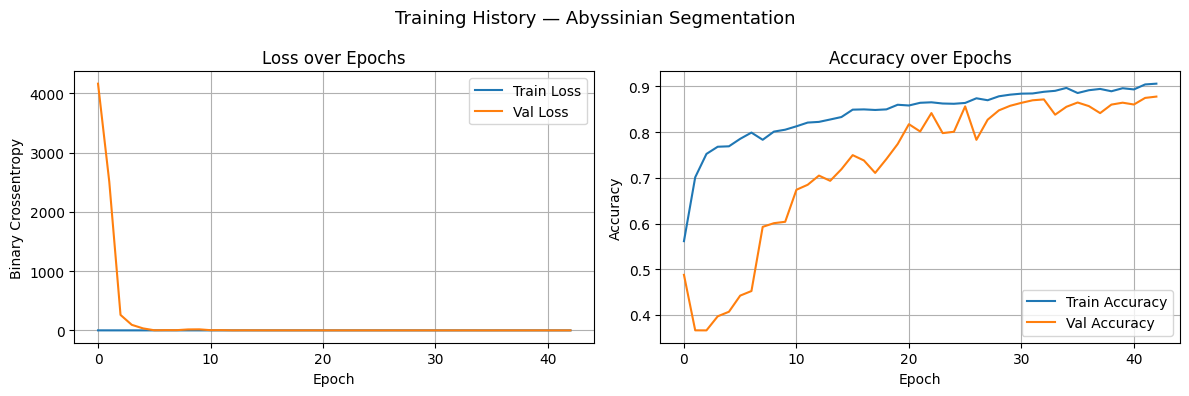

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Crossentropy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['accuracy'],     label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Accuracy over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Training History — Abyssinian Segmentation', fontsize=13)
plt.tight_layout()
plt.savefig('loss_plot.png', dpi=120)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step


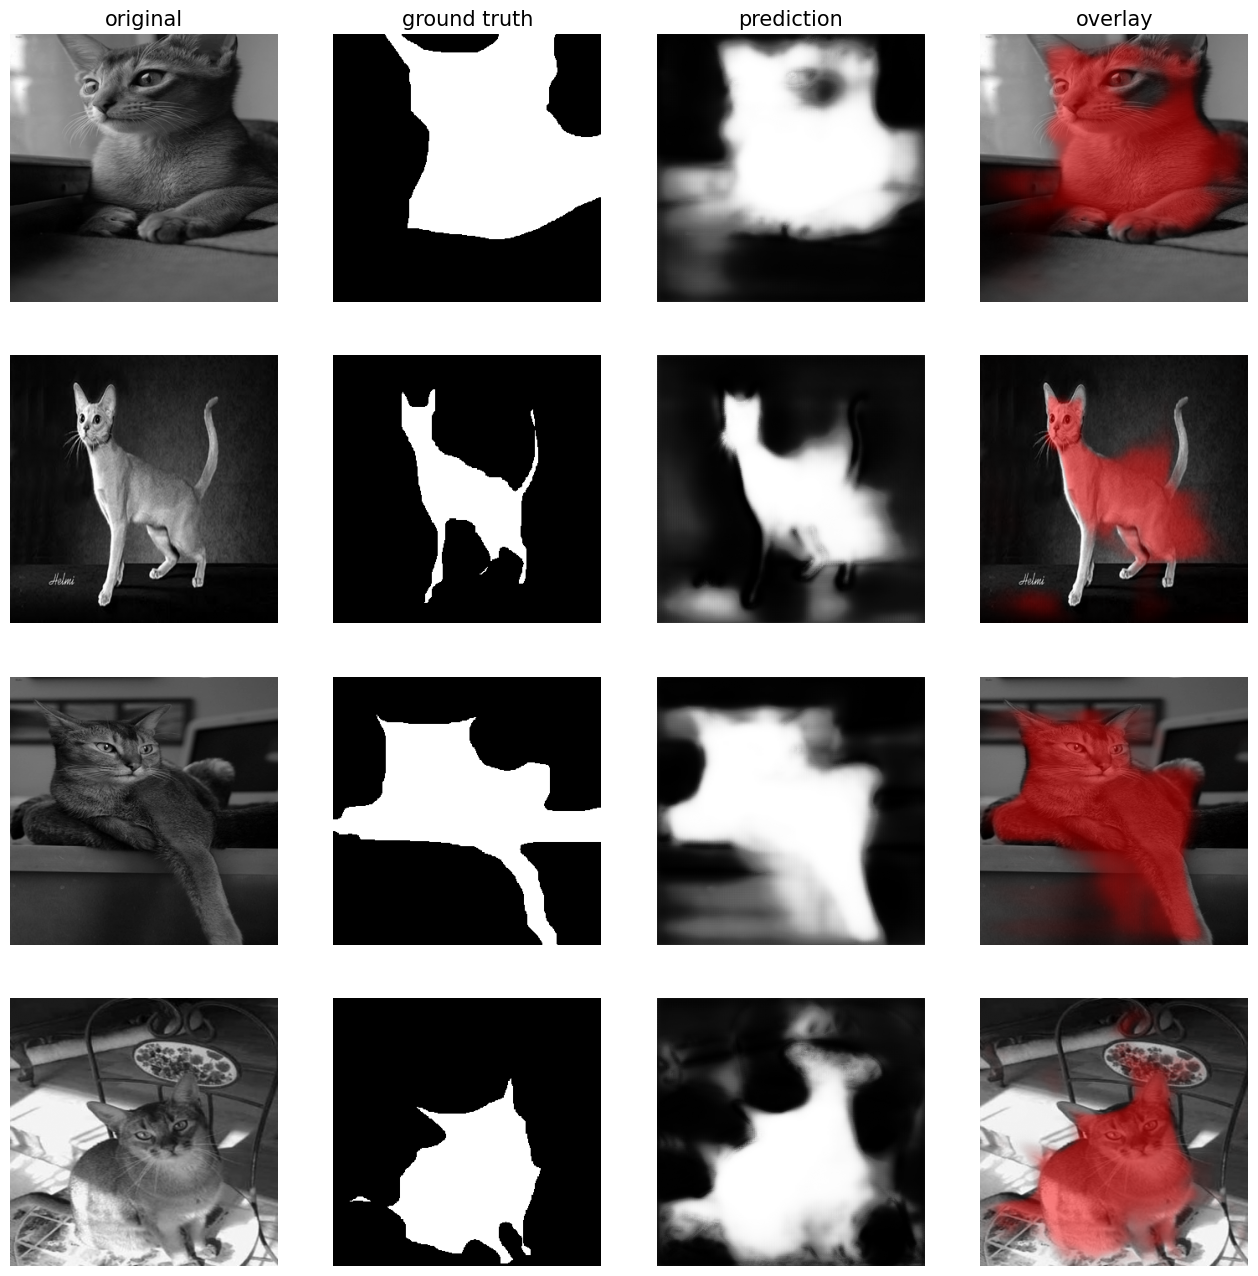

In [10]:
evaluation_result = model.evaluate(X_test, y_test)
print("Loss:    ", evaluation_result[0])
print("Accuracy:", evaluation_result[1])

for i in range(3):
    idx = np.random.randint(0, len(X_test))
    image = X_test[idx]
    mask  = y_test[idx]
    pred  = model.predict(np.expand_dims(image, axis=0), verbose=0)[0]
    pred_bin = (pred > 0.5).astype(np.uint8)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(image[:, :, 0], cmap='gray');    axes[0].set_title('Image');      axes[0].axis('off')
    axes[1].imshow(mask[:, :, 0],  cmap='gray');    axes[1].set_title('Ground Truth'); axes[1].axis('off')
    axes[2].imshow(pred_bin[:, :, 0], cmap='gray'); axes[2].set_title('Prediction'); axes[2].axis('off')
    plt.tight_layout()
    plt.show()